In [43]:
import pandas as pd
import numpy as np

df = pd.read_csv("HR_data.csv")

print(df.head())

   Unnamed: 0    HR_Mean  HR_Median    HR_std  HR_Min  HR_Max     HR_AUC  \
0           0  77.965186      78.00  3.345290   73.23   83.37  22924.945   
1           1  70.981097      70.57  2.517879   67.12   78.22  21930.400   
2           2  73.371959      73.36  3.259569   67.88   80.22  21647.085   
3           3  78.916822      77.88  4.054595   72.32   84.92  25258.905   
4           4  77.322226      74.55  6.047603   70.52   90.15  23890.565   

     Round   Phase  Individual  Puzzler  Frustrated Cohort  
0  round_3  phase3           1        1           1   D1_1  
1  round_3  phase2           1        1           5   D1_1  
2  round_3  phase1           1        1           0   D1_1  
3  round_2  phase3           1        1           1   D1_1  
4  round_2  phase2           1        1           5   D1_1  


In [22]:
#X = df.drop('Frustrated', axis=1)

features = [
    "HR_Mean",
    "HR_Median",
    "HR_std",
    "HR_Min",
    "HR_Max",
    "HR_AUC",
    "Puzzler",
    "Phase"
]

df["Phase"] = df["Phase"].replace({
    "phase1": 1,
    "phase2": 2,
    "phase3": 3
})

X = df[features]


y = df["Frustrated"]


In [27]:
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score

groups = df["Individual"]

cv = GroupKFold(n_splits=7)

In [23]:
train_idx, test_idx = next(cv.split(X, y, groups))
print(train_idx)
print(test_idx)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101
 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119
 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155]
[ 72  73  74  75  76  77  78  79  80  81  82  83 156 157 158 159 160 161
 162 163 164 165 166 167]


In [34]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

lg_scores = []

for train_idx, test_idx in cv.split(X, y, groups):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    score = balanced_accuracy_score(y_test, y_pred)
    lg_scores.append(score)

print(lg_scores)
print("Mean:", sum(lg_scores) / len(lg_scores))





[0.05, 0.07142857142857142, 0.23214285714285715, 0.041666666666666664, 0.27976190476190477, 0.08333333333333333, 0.1111111111111111]
Mean: 0.12420634920634921


/Users/idadanneskiold-samsoe/miniforge3/envs/dtu02451/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_scores = []

for train_idx, test_idx in cv.split(X, y, groups):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)

    score = balanced_accuracy_score(y_test, y_pred)
    rf_scores.append(score)

    

print(rf_scores)
print("Mean:", sum(rf_scores) / len(rf_scores))

/Users/idadanneskiold-samsoe/miniforge3/envs/dtu02451/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/idadanneskiold-samsoe/miniforge3/envs/dtu02451/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


[0.12916666666666665, 0.023809523809523808, 0.07142857142857142, 0.06666666666666667, 0.18253968253968253, 0.047619047619047616, 0.20555555555555557]
Mean: 0.1038265306122449


/Users/idadanneskiold-samsoe/miniforge3/envs/dtu02451/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/idadanneskiold-samsoe/miniforge3/envs/dtu02451/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [37]:
def frustration_group(x):
    if x <= 2:
        return 0
    elif x <= 5:
        return 1
    else:
        return 2

y = df["Frustrated"].apply(frustration_group)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

lg_scores = []

for train_idx, test_idx in cv.split(X, y, groups):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    score = balanced_accuracy_score(y_test, y_pred)
    lg_scores.append(score)

print(lg_scores)
print("Mean:", sum(lg_scores) / len(lg_scores))


[0.3333333333333333, 0.23529411764705885, 0.3333333333333333, 0.43452380952380953, 0.4666666666666667, 0.3333333333333333, 0.4117647058823529]
Mean: 0.36403561424569825


In [41]:
def frustration_group(x):
    if x <= 2:
        return 0
    elif x <= 5:
        return 1
    else:
        return 2

y = df["Frustrated"].apply(frustration_group)

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_scores = []

for train_idx, test_idx in cv.split(X, y, groups):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)

    score = balanced_accuracy_score(y_test, y_pred)
    rf_scores.append(score)

    

print(rf_scores)
print("Mean:", sum(rf_scores) / len(rf_scores))


[0.3666666666666667, 0.2235294117647059, 0.4708994708994709, 0.4077380952380952, 0.4555555555555556, 0.4791666666666667, 0.6386554621848739]
Mean: 0.4346016184251478


/Users/idadanneskiold-samsoe/miniforge3/envs/dtu02451/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [42]:
from scipy.stats import ttest_rel

stat, p = ttest_rel(rf_scores, lg_scores)

print("t-statistic:", stat)
print("p-value:", p)

t-statistic: 1.8842782696767317
p-value: 0.10850949116713582


In [48]:

print("LR scores:", lg_scores)
print("LR mean:", np.mean(lg_scores))
print("LR std:", np.std(lg_scores))

print("RF scores:", rf_scores)
print("RF mean:", np.mean(rf_scores))
print("RF std:", np.std(rf_scores))

LR scores: [0.3333333333333333, 0.23529411764705885, 0.3333333333333333, 0.43452380952380953, 0.4666666666666667, 0.3333333333333333, 0.4117647058823529]
LR mean: 0.36403561424569825
LR std: 0.07288155546519462
RF scores: [0.3666666666666667, 0.2235294117647059, 0.4708994708994709, 0.4077380952380952, 0.4555555555555556, 0.4791666666666667, 0.6386554621848739]
RF mean: 0.4346016184251478
RF std: 0.11666123069221607


<Axes: xlabel='Frustrated'>

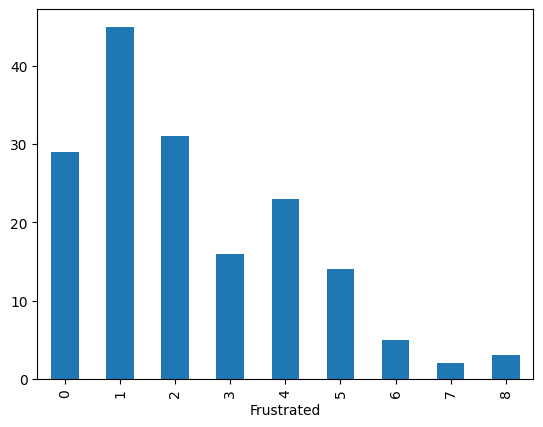

In [45]:
df["Frustrated"].value_counts().sort_index().plot.bar()

/var/folders/0j/dj48f6k13p53sr791tjfbgs80000gn/T/ipykernel_21117/949555836.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lg_scores, rf_scores],


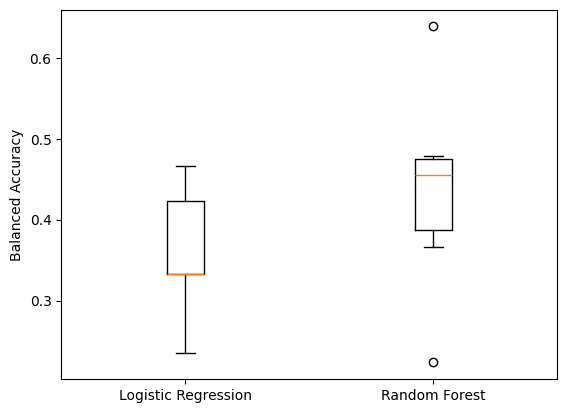

In [47]:
import matplotlib.pyplot as plt

plt.boxplot([lg_scores, rf_scores],
            labels=["Logistic Regression", "Random Forest"])

plt.ylabel("Balanced Accuracy")
plt.show()